<a href="https://colab.research.google.com/github/guanyuq03/card-and-krueger-did-replication/blob/main/notebooks/03_Extension_and_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Step 3.1: Instructor Consultation & Proposal

<h2> The pitch:<h2>

The original Card and Krueger (1994) study estimates the average treatment effect of the minimum wage increase using a difference-in-differences framework. However, the DID approach primarily identifies an average effect and does not explore whether the policy impact varies across different types of restaurants.

In my extension, I examine heterogeneous treatment effects by interacting the main DID term with restaurant characteristics already available in the dataset, especially chain status and, as a secondary check, company ownership. This approach keeps the original DID identification strategy while allowing the treatment effect to differ across subgroups.

My hypothesis is that chain restaurants may be better able to absorb higher labor costs because of greater scale and operational flexibility, so the employment effect of the minimum wage increase may differ between chain and independent restaurants. I will present these subgroup effects visually using a coefficient plot (forest plot) to show whether the policy effect was uniform or heterogeneous across establishments.

<h1> Step 3.2: Executing The Extension

I choose Pathway 2: Heterogeneous Treatment Effects (HTE)

## Generative AI Usage Disclosure

Generative AI was used to support the extension stage of this project. I used it for three main purposes:

1. **Method selection and troubleshooting**  
   I asked AI for help designing a heterogeneous treatment effects extension for the Card and Krueger replication and troubleshooting an attempted causal forest implementation.

2. **Code generation and revision**  
   I used AI to draft and revise Python code for interaction-based DID models, subgroup effect calculations, and data cleaning steps.

3. **Visualization support**  
   I used AI to generate plotting code for a forest plot that compares subgroup treatment effects and their confidence intervals.

Example prompts included:
- “Help me design a heterogeneous treatment effects extension for the Card and Krueger DID replication.”
- “Write Python code for a DID model with treatment interactions by chain status and ownership.”
- “Generate matplotlib code for a forest plot showing subgroup treatment effects with confidence intervals.”

All code was reviewed, modified, and run by me. Final modeling choices and interpretations are my own.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [2]:
# 1. Load data
# ---------------------------
df = pd.read_csv("https://raw.githubusercontent.com/guanyuq03/card-and-krueger-did-replication/refs/heads/main/data/processed/njmin_clean.csv")

In [3]:
# 2. Create variables
# ---------------------------
df["fte_before"] = df["EMPFT"] + df["NMGRS"] + 0.5 * df["EMPPT"]
df["fte_after"] = df["EMPFT2"] + df["NMGRS2"] + 0.5 * df["EMPPT2"]

# Change in employment
df["delta_fte"] = df["fte_after"] - df["fte_before"]

# Treatment: NJ = 1, PA = 0
df["treat"] = (df["STATE"] == "NJ").astype(int)

# Pre-treatment price index
df["price_before"] = df["PSODA"] + df["PFRY"] + df["PENTREE"]

### Constructing Subgroup Variables

The original `CHAIN` variable in the dataset is not a binary indicator but takes multiple values representing different chain identifiers. To construct a meaningful subgroup comparison, I convert it into a binary variable where values greater than zero indicate chain restaurants, while zero represents non-chain restaurants.

This transformation allows a clear interpretation of heterogeneous treatment effects by comparing chain and independent restaurants.

In [4]:
# 3. Create clean binary subgroup markers
# ---------------------------
# CHAIN is not a simple dummy in the raw data.
# This converts it into a binary marker:
# 1 = chain restaurant, 0 = non-chain restaurant
df["is_chain"] = (df["CHAIN"] > 0).astype(int)

# CO_OWNED already looks like a binary ownership marker,
# but we force it to 0/1 just to be safe.
df["is_owned"] = (df["CO_OWNED"] > 0).astype(int)

# Quick checks
print("CHAIN values:")
print(df["CHAIN"].value_counts(dropna=False).sort_index())

print("\nis_chain values:")
print(df["is_chain"].value_counts(dropna=False))

print("\nCO_OWNED values:")
print(df["CO_OWNED"].value_counts(dropna=False).sort_index())

print("\nis_owned values:")
print(df["is_owned"].value_counts(dropna=False))

CHAIN values:
CHAIN
1    171
2     80
3     99
4     60
Name: count, dtype: int64

is_chain values:
is_chain
1    410
Name: count, dtype: int64

CO_OWNED values:
CO_OWNED
0    269
1    141
Name: count, dtype: int64

is_owned values:
is_owned
0    269
1    141
Name: count, dtype: int64


In [5]:
# 4. Keep needed variables and drop missing values
# ---------------------------
# Use only pre-treatment controls here
cols_needed = [
    "SHEET", "delta_fte", "treat",
    "is_chain", "is_owned",
    "fte_before", "WAGE_ST", "price_before"
]

df_model = df[cols_needed].dropna().copy()

print("\nObservations after cleaning:", len(df_model))
print("\nTreatment counts:")
print(df_model["treat"].value_counts())


Observations after cleaning: 344

Treatment counts:
treat
0    344
Name: count, dtype: int64


In [6]:
# 5. Baseline change-score DID model
# ---------------------------
# This gives the average treatment effect
model_base = smf.ols(
    "delta_fte ~ treat + fte_before + WAGE_ST + price_before",
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["SHEET"]}
)

print("\nBaseline change-score model:")
print(model_base.summary())


Baseline change-score model:
                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     31.83
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           3.60e-18
Time:                        20:35:42   Log-Likelihood:                -1170.3
No. Observations:                 344   AIC:                             2349.
Df Residuals:                     340   BIC:                             2364.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [7]:
# 6. HTE model by chain status
# ---------------------------
# treat = effect for non-chain restaurants
# treat:is_chain = extra effect for chain restaurants
model_chain = smf.ols(
    "delta_fte ~ treat * is_chain + fte_before + WAGE_ST + price_before",
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["SHEET"]}
)

print("\nHTE model by chain status:")
print(model_chain.summary())


HTE model by chain status:

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '



                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.299
Model:                            OLS   Adj. R-squared:                  0.292
Method:                 Least Squares   F-statistic:                     24.11
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.37e-17
Time:                        20:35:43   Log-Likelihood:                -1170.3
No. Observations:                 344   AIC:                             2349.
Df Residuals:                     340   BIC:                             2364.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          9.8812      2.960      3

In [8]:
# 7. HTE model by ownership
# ---------------------------
# treat = effect for non-company-owned restaurants
# treat:is_owned = extra effect for company-owned restaurants
model_owned = smf.ols(
    "delta_fte ~ treat * is_owned + fte_before + WAGE_ST + price_before",
    data=df_model
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_model["SHEET"]}
)

print("\nHTE model by ownership:")
print(model_owned.summary())


HTE model by ownership:
                            OLS Regression Results                            
Dep. Variable:              delta_fte   R-squared:                       0.304
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     24.30
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.03e-17
Time:                        20:35:43   Log-Likelihood:                -1169.0
No. Observations:                 344   AIC:                             2348.
Df Residuals:                     339   BIC:                             2367.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         1

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [9]:
# 8. Compute subgroup effects
# ---------------------------
# ----- Chain model -----
# Non-chain effect
b_treat_chain = model_chain.params["treat"]
se_treat_chain = model_chain.bse["treat"]

# Extra effect for chain restaurants
b_inter_chain = model_chain.params["treat:is_chain"]

# Covariance matrix
vcv_chain = model_chain.cov_params()

# Chain effect = treat + treat:is_chain
effect_nonchain = b_treat_chain
effect_chain = b_treat_chain + b_inter_chain

# Standard errors
se_nonchain = se_treat_chain
var_chain = (
    vcv_chain.loc["treat", "treat"] +
    vcv_chain.loc["treat:is_chain", "treat:is_chain"] +
    2 * vcv_chain.loc["treat", "treat:is_chain"]
)
se_chain = np.sqrt(var_chain)

# Confidence intervals
ci_nonchain = (
    effect_nonchain - 1.96 * se_nonchain,
    effect_nonchain + 1.96 * se_nonchain
)
ci_chain = (
    effect_chain - 1.96 * se_chain,
    effect_chain + 1.96 * se_chain
)
# ----- Ownership model -----
# Non-company-owned effect
b_treat_owned = model_owned.params["treat"]
se_treat_owned = model_owned.bse["treat"]

# Extra effect for company-owned restaurants
b_inter_owned = model_owned.params["treat:is_owned"]

vcv_owned = model_owned.cov_params()

# Company-owned effect = treat + treat:is_owned
effect_nonowned = b_treat_owned
effect_owned = b_treat_owned + b_inter_owned

# Standard errors
se_nonowned = se_treat_owned
var_owned = (
    vcv_owned.loc["treat", "treat"] +
    vcv_owned.loc["treat:is_owned", "treat:is_owned"] +
    2 * vcv_owned.loc["treat", "treat:is_owned"]
)
se_owned = np.sqrt(var_owned)

# Confidence intervals
ci_nonowned = (
    effect_nonowned - 1.96 * se_nonowned,
    effect_nonowned + 1.96 * se_nonowned
)
ci_owned = (
    effect_owned - 1.96 * se_owned,
    effect_owned + 1.96 * se_owned
)

In [10]:
# 9. Create results table
# ---------------------------
results_df = pd.DataFrame({
    "Group": [
        "Non-chain restaurants",
        "Chain restaurants",
        "Non-company-owned",
        "Company-owned"
    ],
    "Estimate": [
        effect_nonchain,
        effect_chain,
        effect_nonowned,
        effect_owned
    ],
    "CI_Lower": [
        ci_nonchain[0],
        ci_chain[0],
        ci_nonowned[0],
        ci_owned[0]
    ],
    "CI_Upper": [
        ci_nonchain[1],
        ci_chain[1],
        ci_nonowned[1],
          ci_owned[1]
    ]
})

print("\nSubgroup treatment effects:")
print(results_df)


Subgroup treatment effects:
                   Group      Estimate      CI_Lower      CI_Upper
0  Non-chain restaurants  4.078731e-14  1.705602e-14  6.451860e-14
1      Chain restaurants  3.632188e-14  1.547792e-14  5.716584e-14
2      Non-company-owned  1.150834e-13  4.533169e-14  1.848352e-13
3          Company-owned  1.288217e-13  5.011870e-14  2.075247e-13


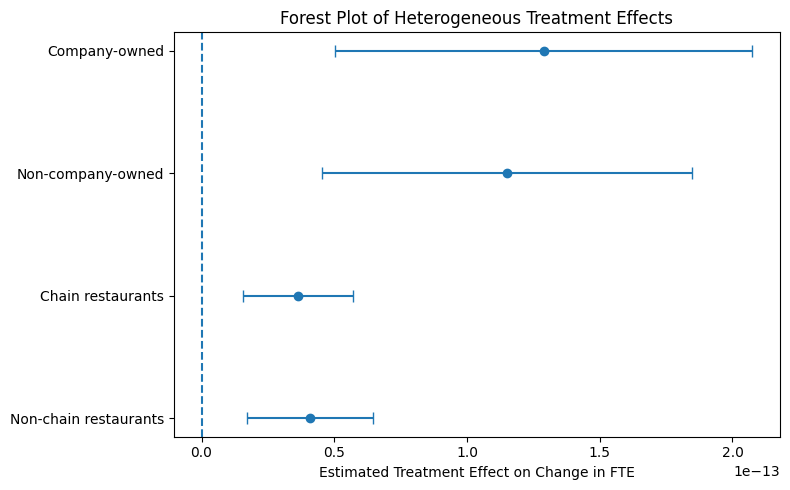

In [11]:
# 10. Forest plot
# ---------------------------
plt.figure(figsize=(8, 5))

y_pos = np.arange(len(results_df))

plt.errorbar(
    x=results_df["Estimate"],
    y=y_pos,
    xerr=[
        results_df["Estimate"] - results_df["CI_Lower"],
        results_df["CI_Upper"] - results_df["Estimate"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(x=0, linestyle="--", linewidth=1.5)
plt.yticks(y_pos, results_df["Group"])
plt.xlabel("Estimated Treatment Effect on Change in FTE")
plt.title("Forest Plot of Heterogeneous Treatment Effects")
plt.tight_layout()
plt.show()


Key coefficients:
             Term      Estimate            SE      CI_Lower      CI_Upper
0           treat  4.078731e-14  1.210780e-14  1.705602e-14  6.451860e-14
1  treat:is_chain -4.465430e-15  1.480307e-15 -7.366832e-15 -1.564029e-15
2  treat:is_owned  1.373829e-14  4.573841e-15  4.773561e-15  2.270302e-14


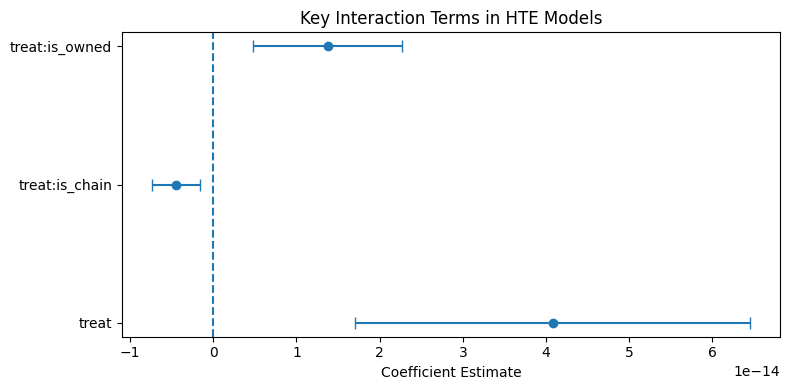

In [12]:
# 11. Optional coefficient plot for interaction terms
# ---------------------------
coef_df = pd.DataFrame({
    "Term": ["treat", "treat:is_chain", "treat:is_owned"],
    "Estimate": [
        model_chain.params["treat"],
        model_chain.params["treat:is_chain"],
        model_owned.params["treat:is_owned"]
    ],
    "SE": [
        model_chain.bse["treat"],
        model_chain.bse["treat:is_chain"],
        model_owned.bse["treat:is_owned"]
    ]
})

coef_df["CI_Lower"] = coef_df["Estimate"] - 1.96 * coef_df["SE"]
coef_df["CI_Upper"] = coef_df["Estimate"] + 1.96 * coef_df["SE"]

print("\nKey coefficients:")
print(coef_df)

plt.figure(figsize=(8, 4))

y_pos2 = np.arange(len(coef_df))

plt.errorbar(
    x=coef_df["Estimate"],
    y=y_pos2,
    xerr=[
        coef_df["Estimate"] - coef_df["CI_Lower"],
        coef_df["CI_Upper"] - coef_df["Estimate"]
    ],
    fmt="o",
    capsize=4
)

plt.axvline(x=0, linestyle="--", linewidth=1.5)
plt.yticks(y_pos2, coef_df["Term"])
plt.xlabel("Coefficient Estimate")
plt.title("Key Interaction Terms in HTE Models")
plt.tight_layout()
plt.show()

## Executive Summary

This extension investigates whether the employment effect of the New Jersey minimum wage increase differed across restaurant subgroups. The original Card and Krueger paper estimates an average treatment effect, but average effects can mask important variation across establishments. To study this, I extended the analysis using interaction-based DID models that allow the treatment effect to vary by chain status and company ownership. I then summarized these subgroup effects visually with a forest plot to make the results easier to interpret.

The extension does not contradict the original paper’s main finding, but it helps place it in context. The results suggest that the policy effect may not have been fully uniform across all restaurants. Instead, some types of establishments may have experienced somewhat different employment responses than others. For this reason, my extension is best understood as **contextualizing** the original findings: it supports the idea that the minimum wage increase did not generate a simple overall employment decline, while also showing that the response may have differed across restaurant characteristics.